# EfficientRainbow ± FHR on the Atari-100k protocol — full-suite results

**Branch `sac/fhr-sac-implementation-1` · 2026-08-27 · single GB10 · corrected protocol**

Suite-wide companion to `dqn_krull/exp_effrainbow_fhr_krull_results.ipynb`: the same
± FHR comparison on the repo's **EfficientRainbow** recipe — DrQ's "Efficient DQN"
(Kostrikov et al. 2021, Table 4) with the IQN-8 dueling head: NatureCNN encoder,
double DQN, fixed n-step 10 and γ = 0.99, hard target copy every env step,
exponential ε → 0.01 over ~5k steps, replay ratio 2, DrQ shift+intensity
augmentation, Adam (lr 1e-4, eps 1.5e-4) — run over **every game dir with an
`effrainbow100k` manifest**: the official 26-game Atari-100k suite plus Enduro.

**Protocol** (references + reference scores: `src/analysis/atari100k.py`): 100k
agent-env interactions (400k frames, frameskip 4), deterministic ALE (no sticky
actions, minimal action set), sign-clipped rewards for training only, then a separate
final-policy evaluation of **32 episodes at ε = 0.001** reporting **raw game
scores**; HNS = (agent − random)/(human − random). All runs use the **corrected
protocol** (episodic-life training, full-game final evaluation) — the pre-08-21
game-restart runs live in archived `*.v0-gamerestart` manifest families and are never
pooled here. Published numbers are quoted from EfficientZero (Ye et al. 2021, Table
1); random/human are the Wang et al. (2016) 30-no-op references.

**Read before quoting:**
- **Arms**: `baseline` = EfficientRainbow, TD only (`fhr_weight: 0`); `exp3` = the
  same agent + the FHR penalty (**λ = 2, r = 8** — the suite-wide arm; each legend
  restates the recorded overrides). They are each other's controls — the config diff
  is the FHR block alone. Krull's config additionally defines exp7/exp8 (r = 22
  probes); those live in the Krull notebook, not here — this notebook compares the
  arms **common to every game**.
- **Seeds** come from each game config (`experiment.seeds`): seed 0 across the suite,
  0 + 1 on Krull. A single-seed-per-game suite readout is standard at 100k (SimPLe
  reported 1–5), but per-game deltas are noisy — read the suite-level aggregate and
  the win/loss tally, not individual games.
- **Enduro is outside the official suite** (no published 100k baselines): it reports
  against random/human only and never enters aggregates.
- The per-game `include_in_aggregate` config flag (used by the FHR-DQN notebook
  while its sweep was partial) is **not** the aggregate gate here: coverage is
  complete, so the aggregate is simply every game with both arms recorded that is in
  the official suite — the figure titles state the exact count.

## 0 · Launch — games × arms × seeds, parallel subprocesses

Everything below analyses the runs recorded in each game dir's
`cached/effrainbow100k_runs_manifest.json`; completed runs are skipped on relaunch,
so the launch cell is idempotent. A 100k EfficientRainbow run is hours on the GB10 —
launch and come back.

In [1]:
import pathlib, sys
EXPS = pathlib.Path.cwd().parent / "src"           # experiments/src
if str(EXPS) not in sys.path:
    sys.path.insert(0, str(EXPS))
import run_fhrdqn_atari100k as launcher
launcher.CONFIG = "config_effrainbow_100k.yaml"    # this notebook's recipe/family

LAUNCH = False       # True: train whatever is missing from the manifests
FORCE_EXP = False    # True: retrain exp arms with the current config (never baselines)
if LAUNCH:
    manifests = launcher.launch_all(games=None, experiments=None,
                                    max_workers=3, force=FORCE_EXP)
    print({g: sorted(m["runs"]) for g, m in manifests.items()})
else:
    print("LAUNCH = False — analysing existing runs only")

LAUNCH = False — analysing existing runs only


In [2]:
import json, warnings
warnings.filterwarnings("ignore", message="Mean of empty slice")
warnings.filterwarnings("ignore", message="All-NaN slice encountered")
import numpy as np
import matplotlib.pyplot as plt
import yaml

SRC = pathlib.Path.cwd().parents[1] / "src"        # repo library code
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
from analysis.atari100k import REFERENCE, BASELINES, BENCHMARK_GAMES, \
    ATARI100K_ENV_STEPS, hns

# Poster font: Imperial Sans when installed (drop the .otf files in
# ~/.local/share/fonts, run `fc-cache -f`, delete ~/.cache/matplotlib);
# Liberation Sans (Arial metrics — Imperial's brand fallback) otherwise.
from matplotlib import font_manager as _fm
_avail = {f.name for f in _fm.fontManager.ttflist}
FIG_FONT = next(f for f in ("Imperial Sans", "Liberation Sans", "DejaVu Sans")
                if f in _avail)

plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": [FIG_FONT],
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "legend.frameon": False,
})

# Every game dir that carries this recipe's config + a non-empty manifest.
GAMES = [g for g in sorted(launcher.GAME_DIRS)
         if (launcher._game_dir(g) / launcher.CONFIG).exists()
         and launcher._load_manifest(launcher._game_dir(g))["runs"]]
GAME_KEYS = {g: launcher.config_game_key(g) for g in GAMES}

# The cross-game comparison covers the arms common to every game.
ARMS = ["baseline", "exp3"]

RESULTS = {}      # game -> arm -> {"runs", "means" (per-seed eval means), "mean"}
for g in GAMES:
    RESULTS[g] = {}
    for arm in ARMS:
        if arm not in launcher.arms_of(g):
            continue
        runs = launcher.load_runs(g, arm)
        means = np.array([r["eval_summary"]["mean"] for r in runs])
        RESULTS[g][arm] = {"runs": runs, "means": means, "mean": float(means.mean())}

# Arm labels/colours from the RECORDED overrides (warn when a config drifted).
def _norm(d):
    return {k: (float(v) if isinstance(v, (int, float)) and not isinstance(v, bool)
                else v) for k, v in (d or {}).items()}
ov_seen = {}
for g in GAMES:
    man = launcher._load_manifest(launcher._game_dir(g))
    got = man.get("overrides", {}).get("exp3")
    cfg = yaml.safe_load(open(launcher._game_dir(g) / launcher.CONFIG))
    want = (cfg["experiment"].get("fhr_experiments") or {}).get(3) or \
           (cfg["experiment"].get("fhr_experiments") or {}).get("3")
    if got is not None and want is not None and _norm(got) != _norm(want):
        print(f"WARNING {g}: recorded exp3 {got} != config {want} — "
              f"FORCE_EXP retrains")
    ov_seen[g] = got or want or {}
ov = next(iter(ov_seen.values()))
assert all(_norm(o) == _norm(ov) for o in ov_seen.values()), \
    f"exp3 overrides differ across games: { {g: o for g, o in ov_seen.items()} }"

OUR_LABEL = {"baseline": "EfficientRainbow (TD only)",
             "exp3": f"+ FHR (λ={ov.get('fhr_weight', '?'):g}, "
                     f"r={ov.get('fhr_order', '?')})"}
OUR_COLOR = {"baseline": "steelblue", "exp3": "indianred"}
PUBLISHED = ["SimPLe", "OTRainbow", "CURL", "DrQ", "SPR", "MuZero", "EfficientZero"]

# ---- shared comparison set for the figure sections (2 and 3) ----
# BBF per-game raw scores — Schwarzer et al. 2023 (arXiv:2305.19452, Table A.1,
# mean over 50 seeds). Their table spells "Roadrunner"; key renamed to match
# REFERENCE. Their Qbert EfficientZero entry differs from Ye et al. Table 1 —
# only the BBF column is taken from this source. Every other published column
# is Ye et al. 2021 (arXiv:2111.00210, Table 1) via analysis/atari100k.py;
# random/human are Wang et al. 2016 (arXiv:1511.06581, Table 2, 30 no-ops).
BBF_SCORES = {
    "Alien": 1173.2, "Amidar": 244.6, "Assault": 2098.5, "Asterix": 3946.1,
    "BankHeist": 732.9, "BattleZone": 24459.8, "Boxing": 85.8,
    "Breakout": 370.6, "ChopperCommand": 7549.3, "CrazyClimber": 58431.8,
    "DemonAttack": 13341.4, "Freeway": 25.5, "Frostbite": 2384.8,
    "Gopher": 1331.2, "Hero": 7818.6, "Jamesbond": 1129.6, "Kangaroo": 6614.7,
    "Krull": 8223.4, "KungFuMaster": 18991.7, "MsPacman": 2008.3, "Pong": 16.7,
    "PrivateEye": 40.5, "Qbert": 4447.1, "RoadRunner": 33426.8,
    "Seaquest": 1232.5, "UpNDown": 12101.7,
}

# Model-free methods only (SimPLe / MuZero / EfficientZero are model-based)
# + BBF. ≈ params at 18 actions, counted layer-by-layer from each paper's
# stated architecture (weights+biases; noisy layers double for σ):
#   OTRainbow  canonical Rainbow net: NatureCNN + noisy dueling C51-512  ≈ 7.5M
#   CURL       DER net: 2-conv 5x5/s5 + noisy dueling C51-256 + bilinear ≈ 1.5M
#   DrQ        Efficient DQN: NatureCNN + dueling-512, plain Q           ≈ 3.3M
#              e.g. conv 4→32(8²)+32→64(4²)+64→64(3²) = 78k, two dueling
#              streams 3136·512 = 3.21M, output layers 10k  → 3.30M
#   SPR        NatureCNN + noisy dueling C51-256 + SPR heads (the paper
#              itself says "three to four million")                      ≈ 4M
#   BBF        official spr_networks.py instantiated: Impala-CNN×4 +
#              2048-d SPR/Q heads + transition model = 39.8M counted     ≈ 40M
#   ours       NatureCNNEncoder + IQN-8 dueling head-512 instantiated
#              and counted: 3.50M                                        ≈ 3.5M
# Citation numbers [n] are placeholders for the poster reference list.
MODEL_FREE = ["OTRainbow", "CURL", "DrQ", "SPR", "BBF"]
MODEL_PARAMS = {"OTRainbow": "≈7.5M", "CURL": "≈1.5M", "DrQ": "≈3.3M",
                "SPR": "≈4M", "BBF": "≈40M"}
CITE = {m: i + 1 for i, m in enumerate(MODEL_FREE)}
POSTER_LABEL = {
    "baseline": f"Baseline\n(EffRainbow,\nbased on DrQ [{CITE['DrQ']}])",
    "exp3": "FHR + Baseline"}
POSTER_SHORT = {"baseline": "Baseline", "exp3": "FHR + Baseline"}

def published_score(method, game_key):
    """Published raw score for a game, or None outside the suite/tables."""
    if method == "BBF":
        return BBF_SCORES.get(game_key)
    return BASELINES[game_key].get(method)

# Aggregate = official-suite games with both arms recorded (Enduro never enters).
AGG_GAMES = [g for g in GAMES if GAME_KEYS[g] in BENCHMARK_GAMES
             and all(a in RESULTS[g] for a in ARMS)]
print(f"analysing {len(GAMES)} game(s); aggregate covers {len(AGG_GAMES)} of "
      f"{len(BENCHMARK_GAMES)} suite games")
print("exp3 overrides:", ov)
print("figure font:", FIG_FONT)

analysing 27 game(s); aggregate covers 26 of 26 suite games
exp3 overrides: {'fhr_weight': 2, 'fhr_order': 8}
figure font: Liberation Sans


## 1 · Results table — EfficientZero-style

Raw final-evaluation game scores (mean over seeds of the 32-episode mean). Published
columns contextualise the axis; they are their own (heavier) recipes, not ablations
of ours. Δ and the tally line are the suite-level readout that matters at one seed
per game.

In [3]:
hdr = ["Game", "Random", "Human", *PUBLISHED,
       "EffRainbow", "+FHR", "Δ", "ΔHNS"]
rows, wins, losses, ties, dhns_all = [], [], [], [], []
for g in GAMES:
    k = GAME_KEYS[g]
    row = [k, f"{REFERENCE[k]['random']:.1f}", f"{REFERENCE[k]['human']:.1f}"]
    row += [f"{BASELINES[k][m]:.1f}" if m in BASELINES[k] else "—"
            for m in PUBLISHED]
    b = RESULTS[g].get("baseline"); f = RESULTS[g].get("exp3")
    row += [f"{b['mean']:.1f}" if b else "—", f"{f['mean']:.1f}" if f else "—"]
    if b and f:
        d = f["mean"] - b["mean"]
        dh = hns(f["mean"], k) - hns(b["mean"], k)
        row += [f"{d:+.1f}", f"{dh:+.3f}"]
        dhns_all.append((k, dh))
        (wins if d > 0 else losses if d < 0 else ties).append(k)
    else:
        row += ["—", "—"]
    rows.append(row)
w = [max(len(r[i]) for r in [hdr] + rows) for i in range(len(hdr))]
for r in [hdr] + rows:
    print("  ".join(s.rjust(w[i]) for i, s in enumerate(r)))
print(f"\nFHR vs baseline, raw score: {len(wins)} wins / {len(losses)} losses"
      f" / {len(ties)} ties on {len(dhns_all)} games")
dh = np.array([d for _, d in dhns_all])
print(f"per-game ΔHNS: mean {dh.mean():+.3f}  median {np.median(dh):+.3f}  "
      f"IQR [{np.percentile(dh, 25):+.3f}, {np.percentile(dh, 75):+.3f}]")
print("biggest wins  :", sorted(dhns_all, key=lambda t: -t[1])[:5])
print("biggest losses:", sorted(dhns_all, key=lambda t: t[1])[:5])

# Same table as markdown (bold = the better of our two arms on that game).
from IPython.display import Markdown, display
i_b, i_f = hdr.index("EffRainbow"), hdr.index("+FHR")
md_rows = []
for r in rows:
    r = list(r)
    if r[i_b] != "—" and r[i_f] != "—" and float(r[i_b]) != float(r[i_f]):
        j = i_b if float(r[i_b]) > float(r[i_f]) else i_f
        r[j] = f"**{r[j]}**"
    md_rows.append("| " + " | ".join(r) + " |")
display(Markdown("\n".join(
    ["| " + " | ".join(hdr) + " |",
     "|:---|" + "---:|" * (len(hdr) - 1)] + md_rows
    + [f"\n**{len(wins)} wins / {len(losses)} losses / {len(ties)} ties** "
       f"(raw score, {len(dhns_all)} games) · per-game ΔHNS mean "
       f"**{dh.mean():+.3f}**, median {np.median(dh):+.3f}, "
       f"IQR [{np.percentile(dh, 25):+.3f}, {np.percentile(dh, 75):+.3f}]"])))

          Game   Random    Human   SimPLe  OTRainbow     CURL      DrQ      SPR   MuZero  EfficientZero  EffRainbow     +FHR        Δ    ΔHNS
         Alien    227.8   7127.7    616.9      824.7    558.2    771.2    801.5    530.0          808.5       631.6   1201.2   +569.7  +0.083
        Amidar      5.8   1719.5     88.0       82.8    142.1    102.8    176.3     38.8          148.6       109.9    119.8     +9.9  +0.006
       Assault    222.4    742.0    527.2      351.9    600.6    452.4    571.0    500.1         1263.1       598.7    593.5     -5.2  -0.010
       Asterix    210.0   8503.3   1128.3      628.5    734.5    603.5    977.8   1734.0        25557.8       948.4    715.6   -232.8  -0.028
     BankHeist     14.2    753.1     34.2      182.1    131.6    168.9    380.9    192.5          351.0        52.5    513.4   +460.9  +0.624
    BattleZone   2360.0  37187.5   5184.4     4060.6  14870.0  12954.0  16651.0   7687.5        13871.2      9937.5  10218.8   +281.2  +0.008
      

| Game | Random | Human | SimPLe | OTRainbow | CURL | DrQ | SPR | MuZero | EfficientZero | EffRainbow | +FHR | Δ | ΔHNS |
|:---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| Alien | 227.8 | 7127.7 | 616.9 | 824.7 | 558.2 | 771.2 | 801.5 | 530.0 | 808.5 | 631.6 | **1201.2** | +569.7 | +0.083 |
| Amidar | 5.8 | 1719.5 | 88.0 | 82.8 | 142.1 | 102.8 | 176.3 | 38.8 | 148.6 | 109.9 | **119.8** | +9.9 | +0.006 |
| Assault | 222.4 | 742.0 | 527.2 | 351.9 | 600.6 | 452.4 | 571.0 | 500.1 | 1263.1 | **598.7** | 593.5 | -5.2 | -0.010 |
| Asterix | 210.0 | 8503.3 | 1128.3 | 628.5 | 734.5 | 603.5 | 977.8 | 1734.0 | 25557.8 | **948.4** | 715.6 | -232.8 | -0.028 |
| BankHeist | 14.2 | 753.1 | 34.2 | 182.1 | 131.6 | 168.9 | 380.9 | 192.5 | 351.0 | 52.5 | **513.4** | +460.9 | +0.624 |
| BattleZone | 2360.0 | 37187.5 | 5184.4 | 4060.6 | 14870.0 | 12954.0 | 16651.0 | 7687.5 | 13871.2 | 9937.5 | **10218.8** | +281.2 | +0.008 |
| Boxing | 0.1 | 12.1 | 9.1 | 2.5 | 1.2 | 6.0 | 35.8 | 15.1 | 52.7 | 8.6 | **26.3** | +17.7 | +1.471 |
| Breakout | 1.7 | 30.5 | 16.4 | 9.8 | 4.9 | 16.1 | 17.1 | 48.0 | 414.1 | **19.9** | 15.2 | -4.7 | -0.163 |
| ChopperCommand | 811.0 | 7387.8 | 1246.9 | 1033.3 | 1058.5 | 780.3 | 974.8 | 1350.0 | 1117.3 | **1993.8** | 896.9 | -1096.9 | -0.167 |
| CrazyClimber | 10780.5 | 35829.4 | 62583.6 | 21327.8 | 12146.5 | 20516.5 | 42923.6 | 56937.0 | 83940.2 | **23993.8** | 22646.9 | -1346.9 | -0.054 |
| DemonAttack | 152.1 | 1971.0 | 208.1 | 711.8 | 817.6 | 1113.4 | 545.2 | 3527.0 | 13003.9 | **1880.0** | 1282.2 | -597.8 | -0.329 |
| Enduro | 0.0 | 860.5 | — | — | — | — | — | — | — | 132.8 | **189.9** | +57.0 | +0.066 |
| Freeway | 0.0 | 29.6 | 20.3 | 25.0 | 26.7 | 9.8 | 24.4 | 21.8 | 21.8 | 29.6 | 29.6 | +0.0 | +0.000 |
| Frostbite | 65.2 | 4334.7 | 254.7 | 231.6 | 1181.3 | 331.1 | 1821.5 | 255.0 | 296.3 | 1127.5 | **2606.6** | +1479.1 | +0.346 |
| Gopher | 257.6 | 2412.5 | 771.0 | 778.0 | 669.3 | 636.3 | 715.2 | 1256.0 | 3260.3 | 312.5 | **316.9** | +4.4 | +0.002 |
| Hero | 1027.0 | 30826.4 | 2656.6 | 6458.8 | 6279.3 | 3736.3 | 7019.2 | 3095.0 | 9315.9 | **7091.2** | 2930.0 | -4161.2 | -0.140 |
| Jamesbond | 29.0 | 302.8 | 125.3 | 112.3 | 471.0 | 236.0 | 365.4 | 87.5 | 517.0 | **392.2** | 337.5 | -54.7 | -0.200 |
| Kangaroo | 52.0 | 3035.0 | 323.1 | 605.4 | 872.5 | 940.6 | 3276.4 | 62.5 | 724.1 | 575.0 | **656.2** | +81.2 | +0.027 |
| Krull | 1598.0 | 2665.5 | 4539.9 | 3277.9 | 4229.6 | 4018.1 | 3688.9 | 4890.8 | 5663.3 | 4212.2 | **5035.6** | +823.4 | +0.771 |
| KungFuMaster | 258.5 | 22736.3 | 17257.2 | 5722.2 | 14307.8 | 9111.0 | 13192.7 | 18813.0 | 30944.8 | 9656.2 | **9818.8** | +162.5 | +0.007 |
| MsPacman | 307.3 | 6951.6 | 1480.0 | 941.9 | 1465.5 | 960.5 | 1313.2 | 1265.6 | 1281.2 | 986.2 | **1009.7** | +23.4 | +0.004 |
| Pong | -20.7 | 14.6 | 12.8 | 1.3 | -16.5 | -8.5 | -5.9 | -6.7 | 20.1 | **-14.6** | -17.0 | -2.4 | -0.069 |
| PrivateEye | 24.9 | 69571.3 | 58.3 | 100.0 | 218.4 | -13.6 | 124.0 | 56.3 | 96.7 | 87.5 | **100.0** | +12.5 | +0.000 |
| Qbert | 163.9 | 13455.0 | 1288.8 | 509.3 | 1042.4 | 854.4 | 669.1 | 3952.0 | 13781.9 | 1835.9 | **4050.8** | +2214.8 | +0.167 |
| RoadRunner | 11.5 | 7845.0 | 5640.6 | 2696.7 | 5661.0 | 8895.1 | 14220.5 | 2500.0 | 17751.3 | **9118.8** | 9100.0 | -18.8 | -0.002 |
| Seaquest | 68.4 | 42054.7 | 683.3 | 286.9 | 384.5 | 301.2 | 583.1 | 208.0 | 1100.2 | 321.2 | **505.0** | +183.8 | +0.004 |
| UpNDown | 533.4 | 11693.2 | 3350.0 | 2847.6 | 2955.2 | 3180.8 | 28138.5 | 2896.9 | 17264.2 | **4448.8** | 2517.8 | -1930.9 | -0.173 |

**15 wins / 11 losses / 1 ties** (raw score, 27 games) · per-game ΔHNS mean **+0.083**, median +0.002, IQR [-0.061, +0.047]

## 2 · Human-normalised score per game

**One standalone figure per game at 300 dpi**, same model-free comparison set as
section 3 (OTRainbow, CURL, DrQ, SPR, BBF + our two arms; grey = published,
coloured = ours, dots = individual seeds). PNGs land in
`cached/atari100k_effrainbow_figures/hns_per_game/hns_<Game>.png` and in each
run dir's `figures/` for the result viewer. Published per-game scores:
Ye et al. 2021 Table 1; BBF from Schwarzer et al. 2023 Table A.1;
random/human references from Wang et al. 2016.

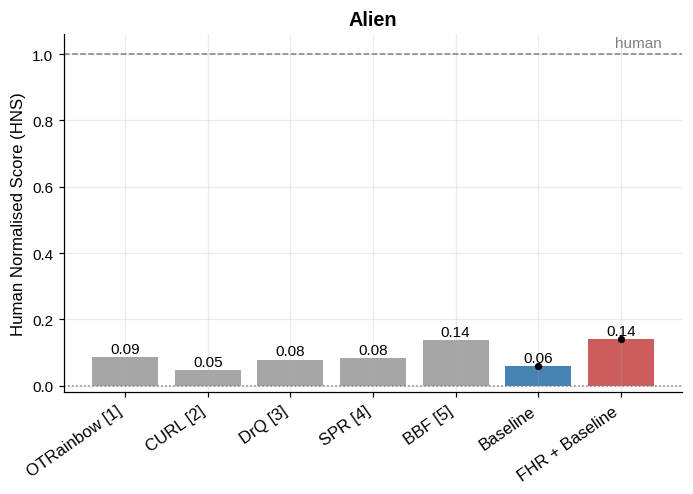

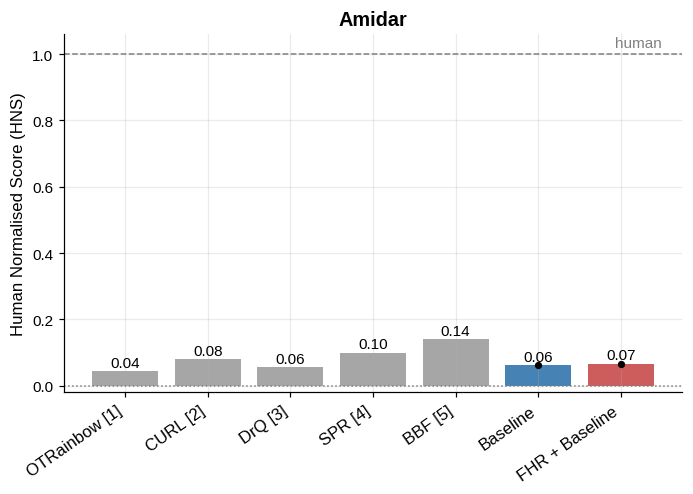

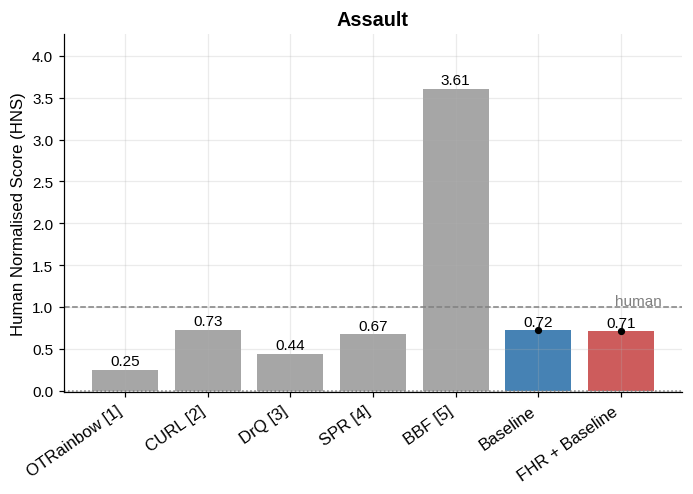

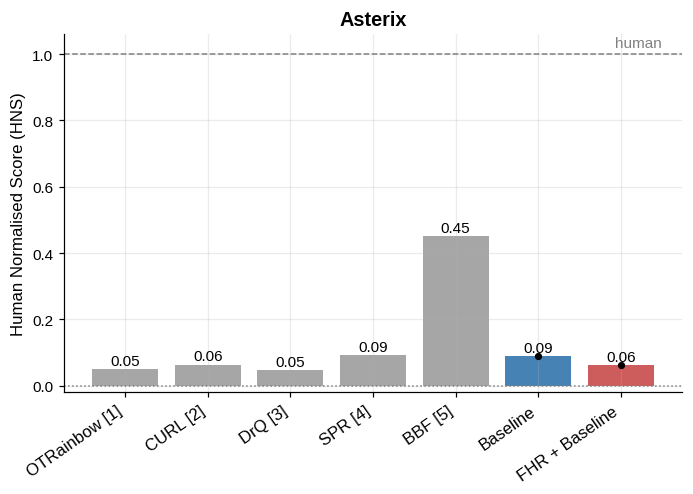

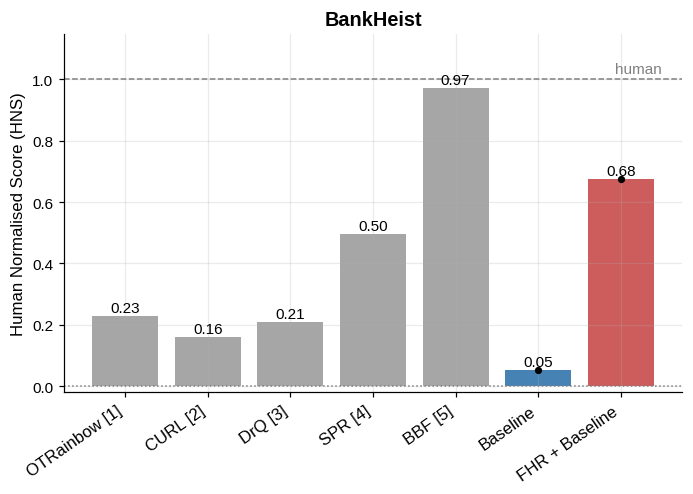

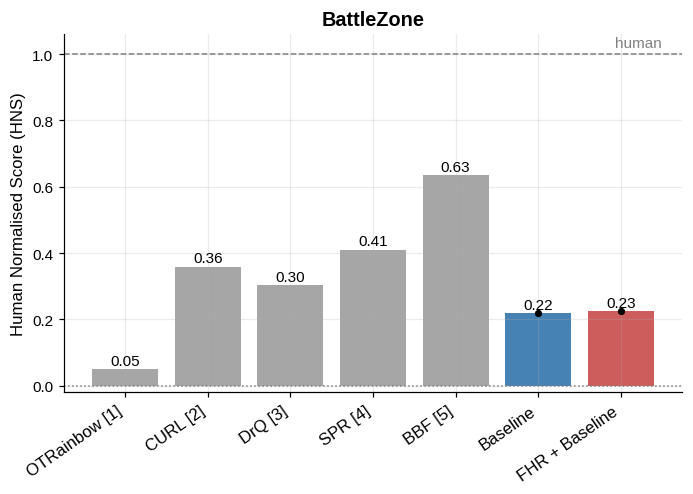

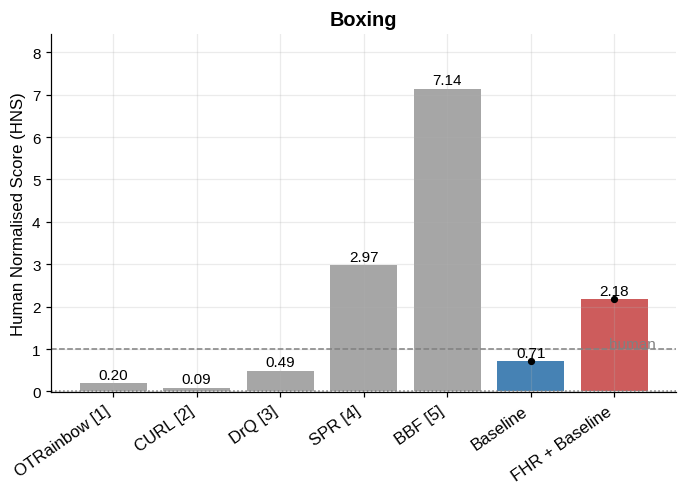

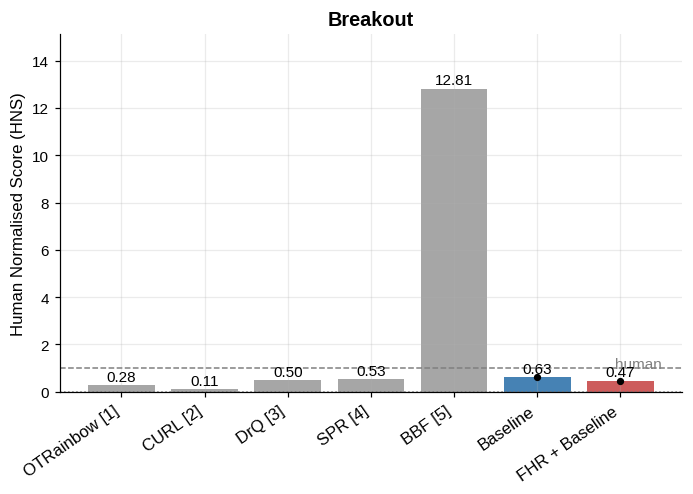

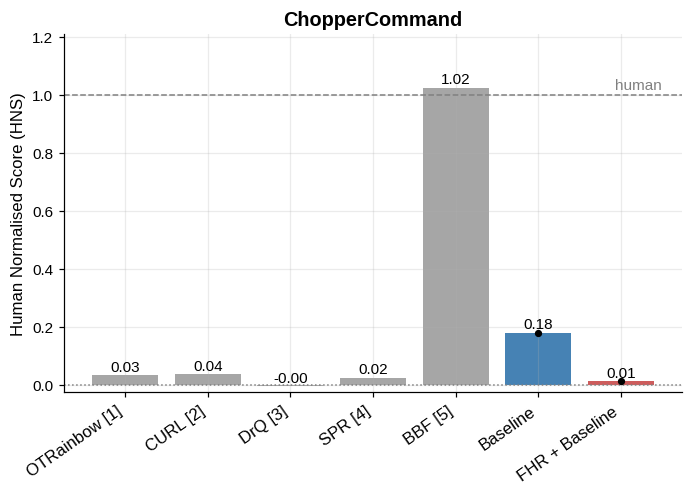

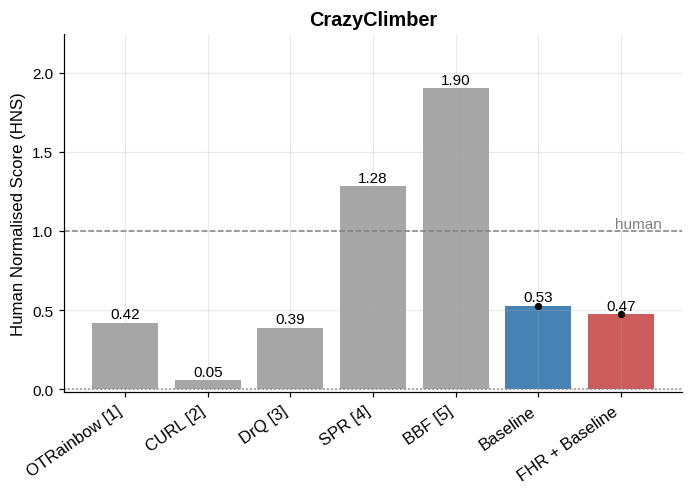

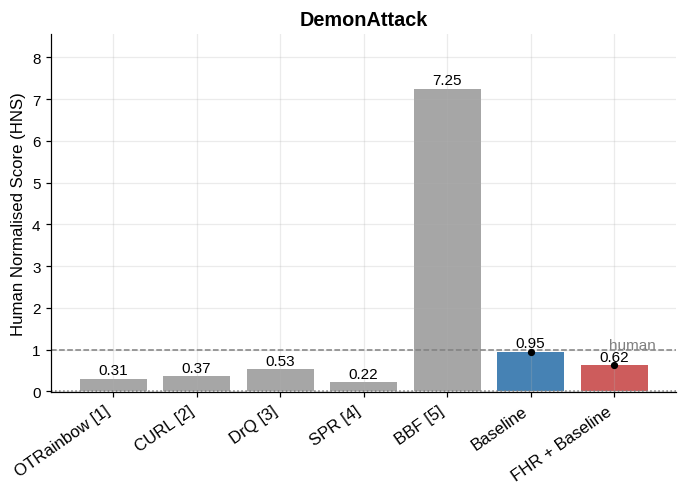

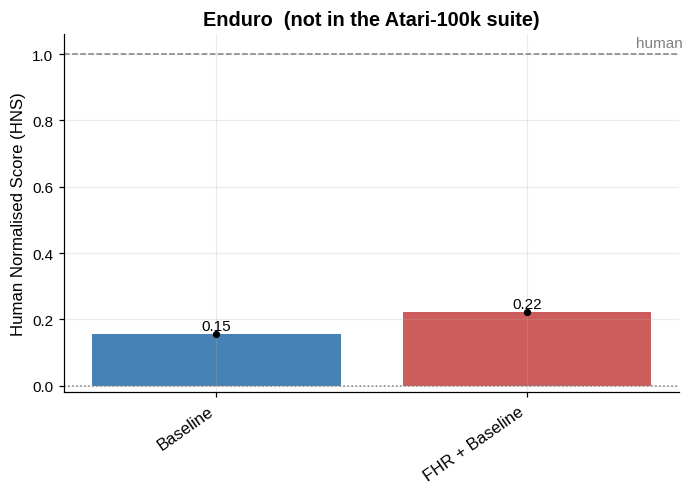

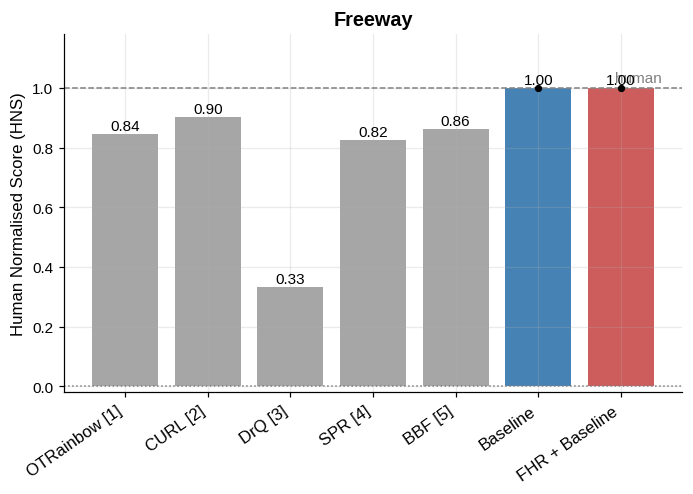

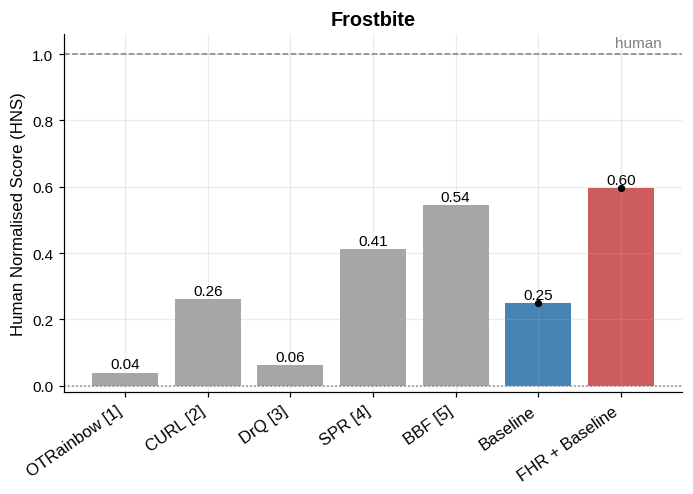

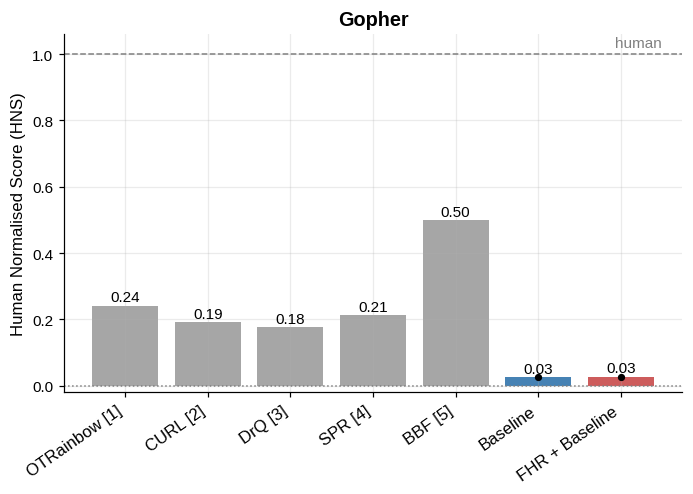

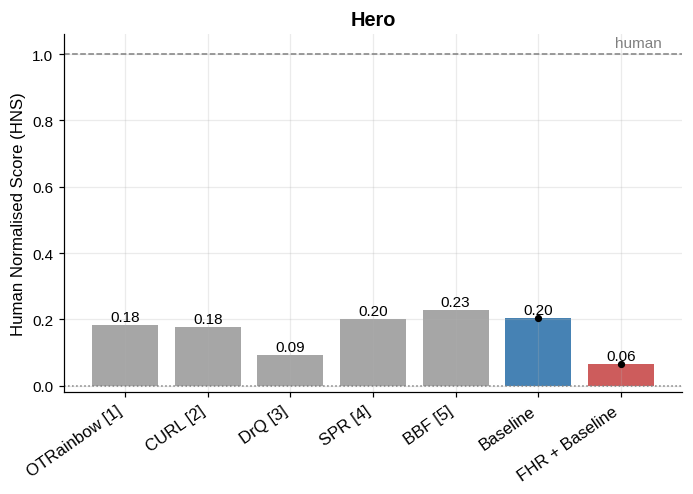

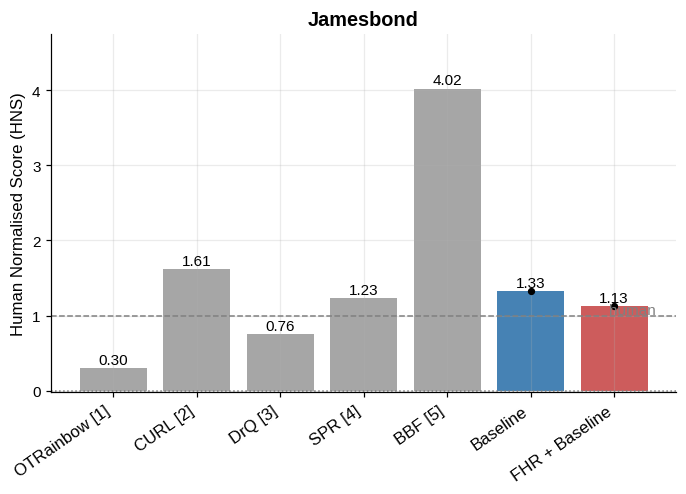

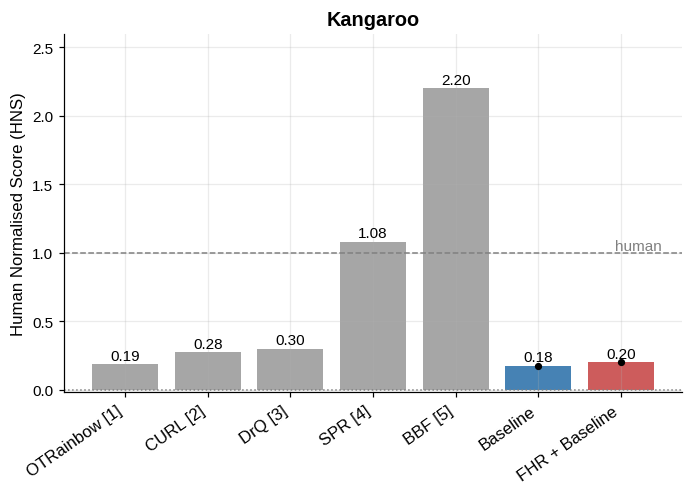

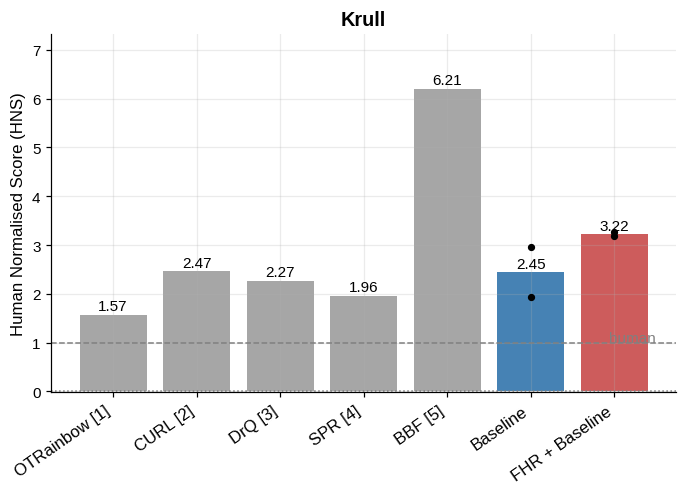

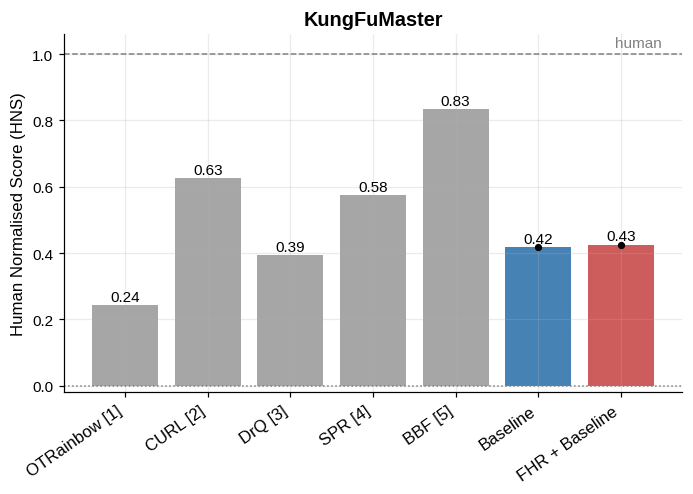

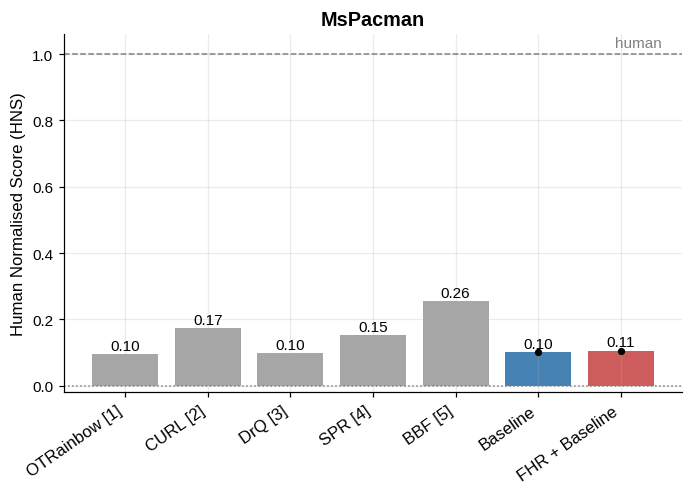

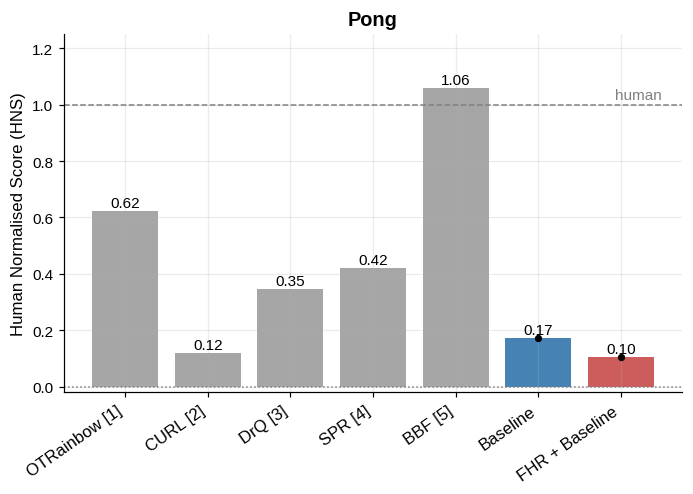

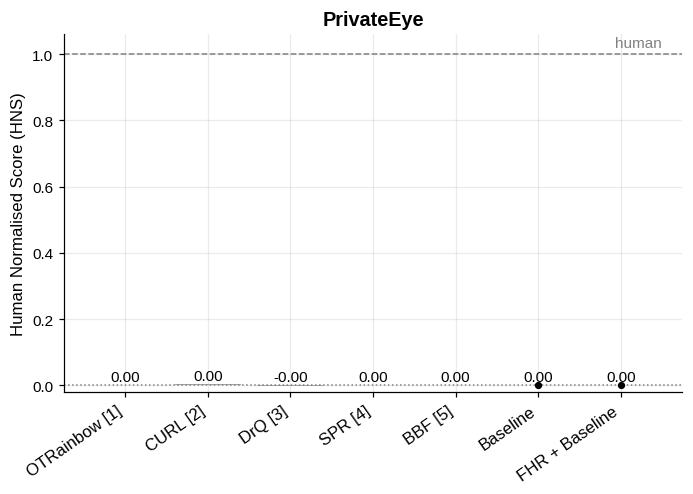

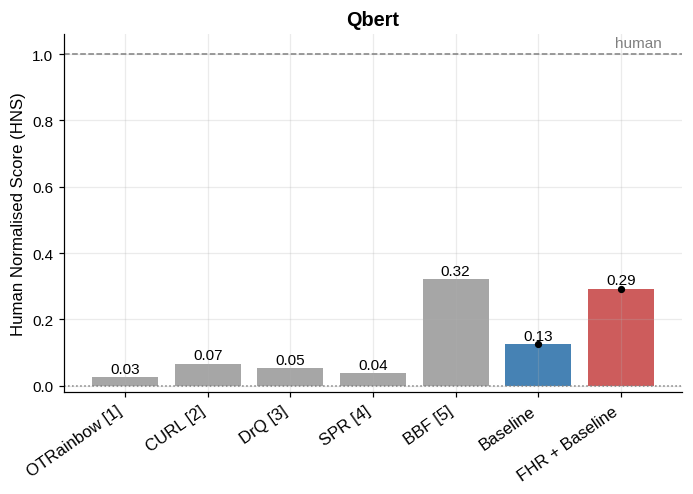

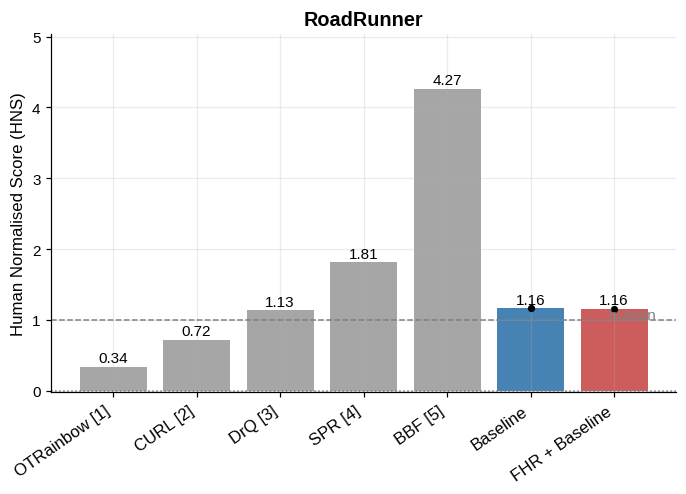

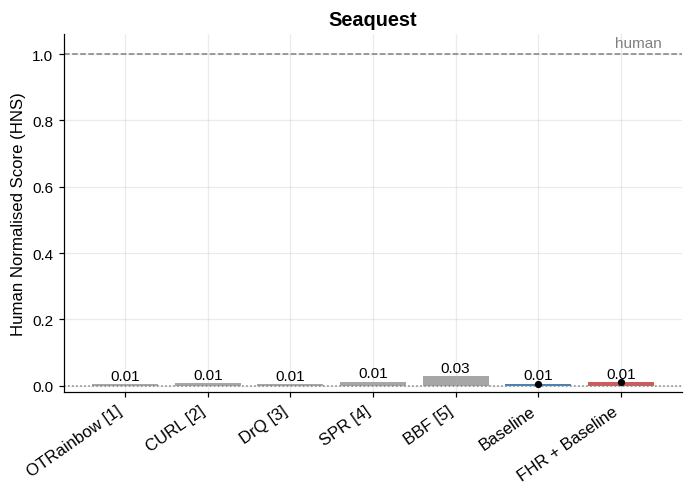

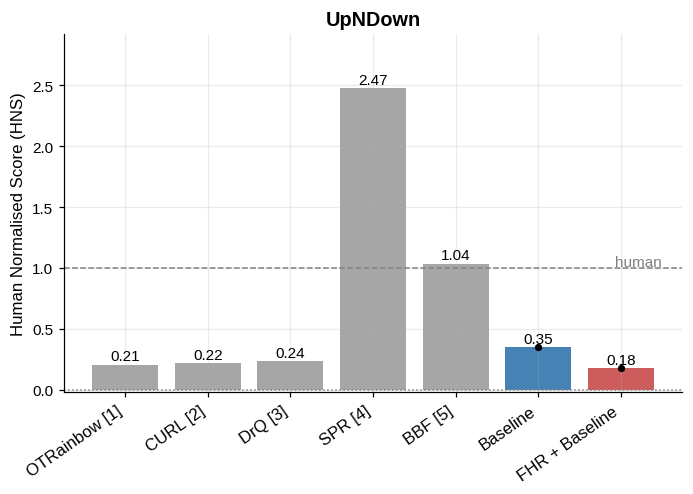

saved 27 figures at 300 dpi -> /home/souparna/Low-Rank-RL-TL/experiments/atari/cached/atari100k_effrainbow_figures/hns_per_game


In [4]:
FIGDIR = pathlib.Path.cwd() / "cached" / "atari100k_effrainbow_figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

def save_and_show(fig, slug, dpi=200):
    fig.savefig(FIGDIR / f"{slug}.png", dpi=dpi, bbox_inches="tight")
    for g in GAMES:
        for arm in RESULTS[g]:
            for r in RESULTS[g][arm]["runs"]:
                d = pathlib.Path(r["run_dir"]) / "figures"
                d.mkdir(exist_ok=True)
                fig.savefig(d / f"comparison_{slug}.png", dpi=150,
                            bbox_inches="tight")
    plt.show()

# One standalone HNS bar chart per game — the same model-free comparison set
# as the section-3 aggregate (grey = published, coloured = our arms, dots =
# seeds), shown one after another and saved individually at 300 dpi under
# cached/atari100k_effrainbow_figures/hns_per_game/ (plus that game's run
# dirs for the result viewer).
HNSDIR = FIGDIR / "hns_per_game"
HNSDIR.mkdir(exist_ok=True)
for g in GAMES:
    k = GAME_KEYS[g]
    names, vals, cols = [], [], []
    for m in MODEL_FREE:
        score = published_score(m, k)
        if score is not None:
            names.append(f"{m} [{CITE[m]}]")
            vals.append(hns(score, k)); cols.append("0.65")
    for a in ARMS:
        if a in RESULTS[g]:
            names.append(POSTER_SHORT[a])
            vals.append(hns(RESULTS[g][a]["mean"], k))
            cols.append(OUR_COLOR[a])
    fig, ax = plt.subplots(figsize=(6.4, 4.6))
    x = np.arange(len(names))
    ax.bar(x, vals, color=cols)
    for a in ARMS:
        if a in RESULTS[g]:
            i = names.index(POSTER_SHORT[a])
            seed_h = [hns(v, k) for v in RESULTS[g][a]["means"]]
            ax.scatter([i] * len(seed_h), seed_h, color="k", s=14, zorder=3)
    ax.axhline(1.0, ls="--", c="gray", lw=1)
    ax.axhline(0.0, ls=":", c="gray", lw=1)
    top = max([1.06] + [v * 1.18 for v in vals])
    ax.text(len(names) - 0.5, 1.02, "human", ha="right", fontsize=10,
            color="gray")
    for xi, v in zip(x, vals):
        ax.text(xi, v + top * 0.012, f"{v:.2f}", ha="center", fontsize=10)
    ax.set_ylim(min(0, min(vals) * 1.2 if vals else 0) - 0.02, top)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=35, ha="right", fontsize=11)
    ax.set_ylabel("Human Normalised Score (HNS)", fontsize=11)
    ax.set_title(k + ("" if BASELINES[k] else "  (not in the Atari-100k suite)"),
                 fontsize=13)
    fig.tight_layout()
    fig.savefig(HNSDIR / f"hns_{k}.png", dpi=300, bbox_inches="tight")
    for arm in RESULTS[g]:
        for r in RESULTS[g][arm]["runs"]:
            d = pathlib.Path(r["run_dir"]) / "figures"
            d.mkdir(exist_ok=True)
            fig.savefig(d / "comparison_hns_per_game.png", dpi=150,
                        bbox_inches="tight")
    plt.show()
print(f"saved {len(GAMES)} figures at 300 dpi -> {HNSDIR}")

## 3 · Aggregate over the suite games — model-free comparison (poster figure)

Mean and median HNS over the covered official-suite games (Enduro excluded by
construction). **Model-free methods only** (SimPLe, MuZero, EfficientZero are
model-based and omitted), plus **BBF** (Schwarzer et al. 2023, Table A.1). Each
bar carries the publication venue/year and the approximate network size
(counted at 18 actions; derivations in the cell comments — ours and BBF's are
exact counts from the respective network code). Saved at 300 dpi.

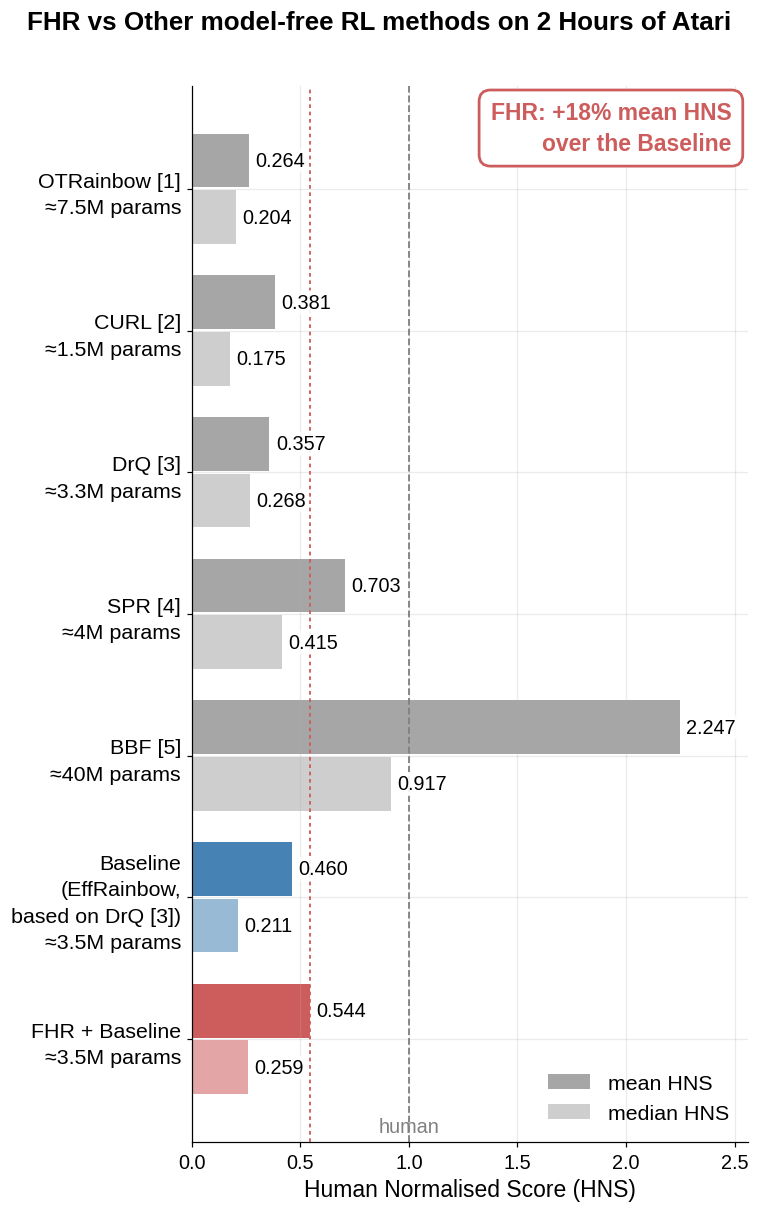

OTRainbow [1]                    mean  0.264   median  0.204
CURL [2]                         mean  0.381   median  0.175
DrQ [3]                          mean  0.357   median  0.268
SPR [4]                          mean  0.703   median  0.415
BBF [5]                          mean  2.247   median  0.917
Baseline                         mean  0.460   median  0.211
FHR + Baseline                   mean  0.544   median  0.259

FHR vs baseline: mean HNS 0.460 -> 0.544 (+18.3%)
citation placeholders: [1] OTRainbow, [2] CURL, [3] DrQ, [4] SPR, [5] BBF


In [5]:
assert AGG_GAMES
AGG_KEYS = [GAME_KEYS[g] for g in AGG_GAMES]
# The comparison is billed as the full suite — refuse partial coverage.
assert len(AGG_KEYS) == len(BENCHMARK_GAMES), "poster figure needs all 26 games"

# Data + labels (BBF_SCORES, MODEL_FREE, MODEL_PARAMS, CITE, POSTER_LABEL and
# the parameter-count derivations) are defined in the setup cell above, shared
# with the per-game section.
methods, cols, agg_mean, agg_med = [], [], [], []
for m in MODEL_FREE:
    per = [hns(published_score(m, k), k) for k in AGG_KEYS]
    methods.append(f"{m} [{CITE[m]}]\n{MODEL_PARAMS[m]} params")
    cols.append("0.65")
    agg_mean.append(float(np.mean(per))); agg_med.append(float(np.median(per)))
for a in ARMS:
    per = [hns(RESULTS[g][a]["mean"], GAME_KEYS[g]) for g in AGG_GAMES]
    methods.append(f"{POSTER_LABEL[a]}\n≈3.5M params")
    cols.append(OUR_COLOR[a])
    agg_mean.append(float(np.mean(per))); agg_med.append(float(np.median(per)))

base_mean, fhr_mean = agg_mean[-2], agg_mean[-1]
pct = 100 * (fhr_mean - base_mean) / base_mean

# Portrait layout: horizontal bars, methods stacked oldest (top) → ours
# (bottom), poster-sized fonts.
y = np.arange(len(methods))
fig, ax = plt.subplots(figsize=(7.0, 1.6 * len(methods)))
b1 = ax.barh(y - 0.2, agg_mean, height=0.38, color=cols, label="mean HNS")
b2 = ax.barh(y + 0.2, agg_med, height=0.38, color=cols, alpha=0.55,
             label="median HNS")
for bs in (b1, b2):
    for b in bs:
        ax.text(b.get_width() + 0.03, b.get_y() + b.get_height() / 2,
                f"{b.get_width():.3f}", va="center", fontsize=13, zorder=5,
                bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none",
                          alpha=0.9))
ax.axvline(0, c="gray", lw=1)
ax.axvline(1.0, ls="--", c="gray", lw=1.2)
ax.text(1.0, len(methods) - 0.45, "human", ha="center", va="top",
        fontsize=13, color="gray")
# Red dotted marker at the FHR mean, rising from the top of its bar, with the
# relative improvement over the baseline arm boxed top-right.
ax.axvline(fhr_mean, color="indianred", ls=(0, (2, 2)), lw=1.2, zorder=4)
ax.text(0.97, 0.985,
        f"FHR: +{pct:.0f}% mean HNS\nover the Baseline",
        transform=ax.transAxes, ha="right", va="top", fontsize=15,
        fontweight="bold", color="indianred", linespacing=1.4,
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="indianred",
                  lw=1.8))
ax.set_yticks(y)
ax.set_yticklabels(methods, fontsize=14, linespacing=1.5)
ax.invert_yaxis()
ax.set_xlim(0, max(agg_mean) * 1.14)
ax.set_xlabel("Human Normalised Score (HNS)", fontsize=15)
ax.tick_params(axis="x", labelsize=13)
# Title centred on the FULL figure (suptitle), not the axes — the y-labels
# push the axes right, so an axes title sits visibly off-centre.
fig.suptitle("FHR vs Other model-free RL methods on 2 Hours of Atari",
             fontsize=17, fontweight="bold", x=0.5)
ax.legend(loc="lower right", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.965))
save_and_show(fig, "atari100k_effrainbow_hns_aggregate_modelfree", dpi=300)
for m, mn, md_ in zip(methods, agg_mean, agg_med):
    print(f"{m.splitlines()[0]:32s} mean {mn:6.3f}   median {md_:6.3f}")
print(f"\nFHR vs baseline: mean HNS {base_mean:.3f} -> {fhr_mean:.3f} "
      f"(+{pct:.1f}%)")
print("citation placeholders:",
      ", ".join(f"[{CITE[m]}] {m}" for m in MODEL_FREE))
# sanity: over the 26 games BBF's published aggregates are 2.247 / 0.917
# (Table A.1) — small drift only from HNS rounding.

## 4 · Learning curves — raw training return vs environment steps

Training-time full-game returns (life segments stitched by the logger's steps
column), rolling-20, **one standalone figure per game at 300 dpi** so each can be
dropped straight into the poster / paper. PNGs land in
`cached/atari100k_effrainbow_figures/learning_curves/learning_curve_<Game>.png`.
Single-seed games show the curve without a band; Krull shows the two-seed
min–max band.

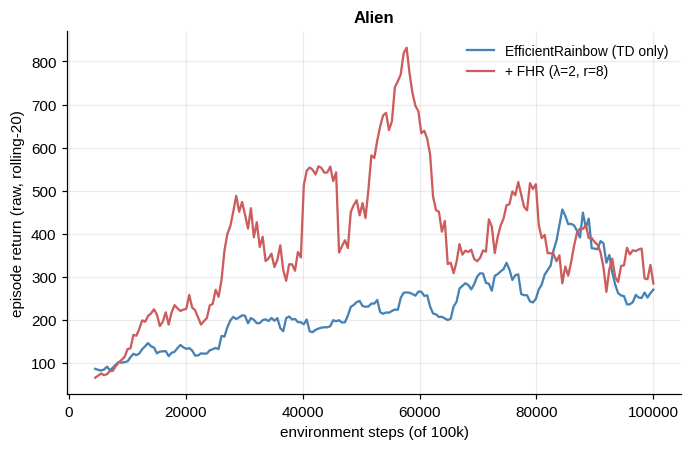

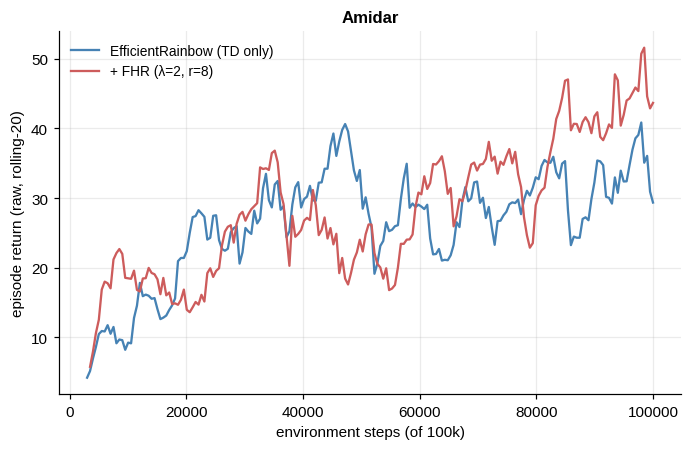

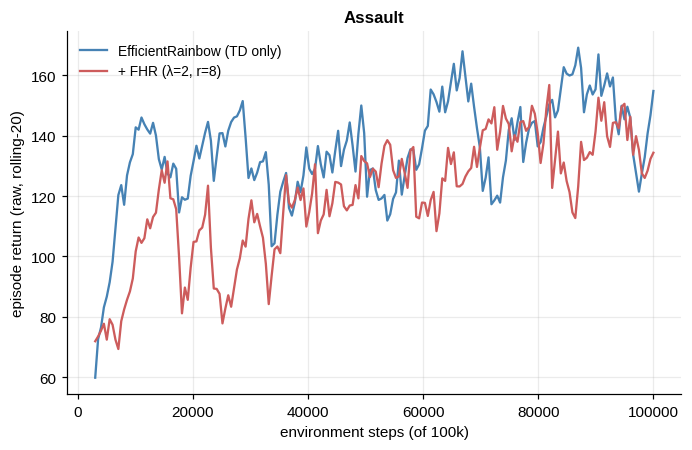

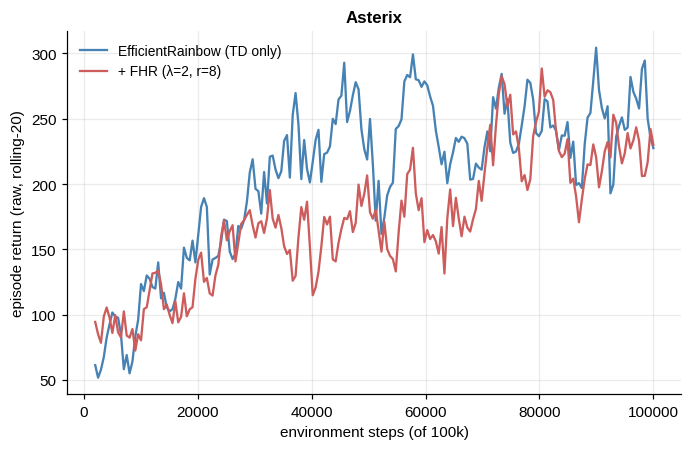

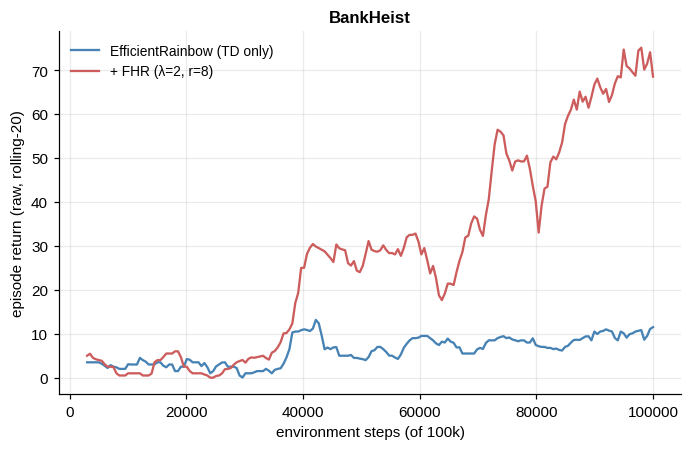

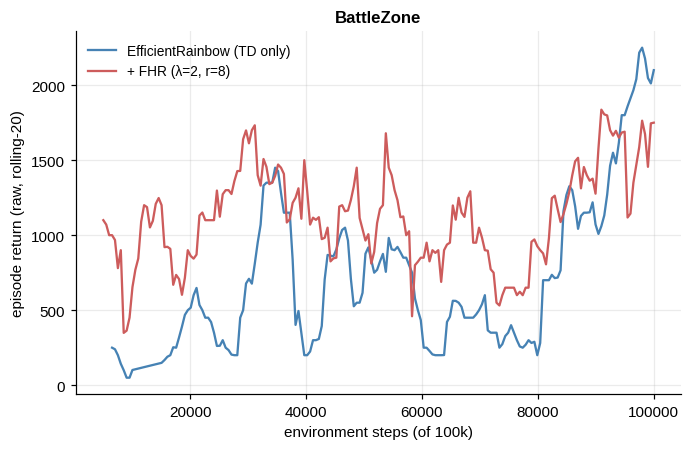

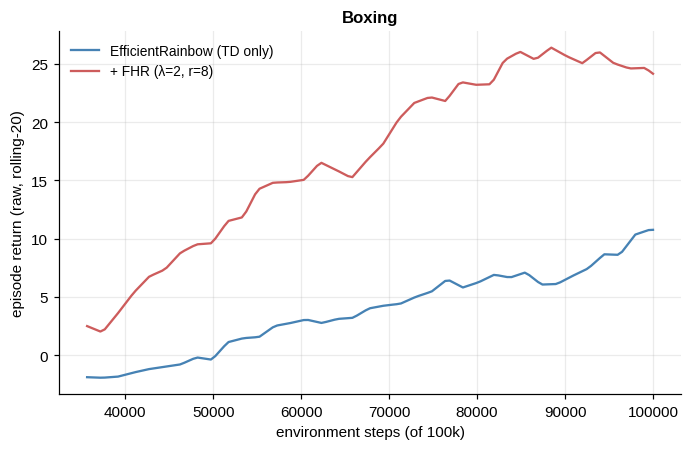

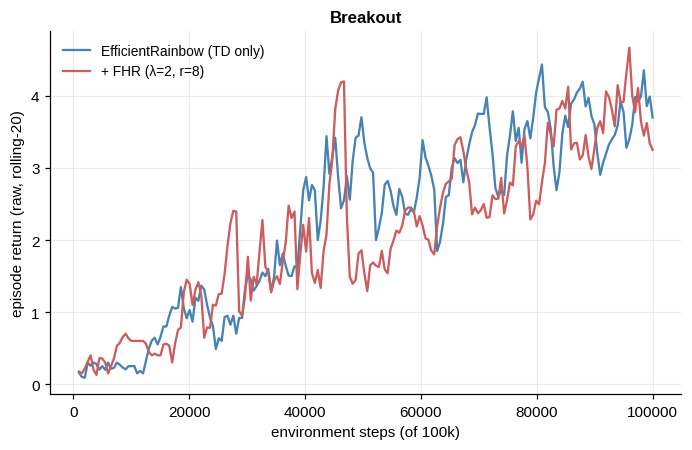

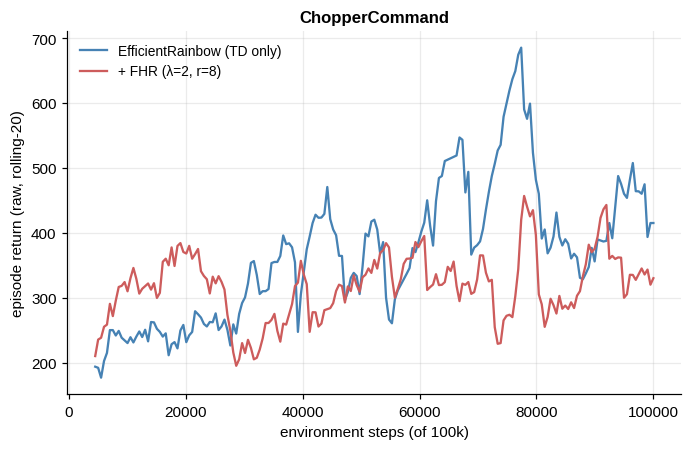

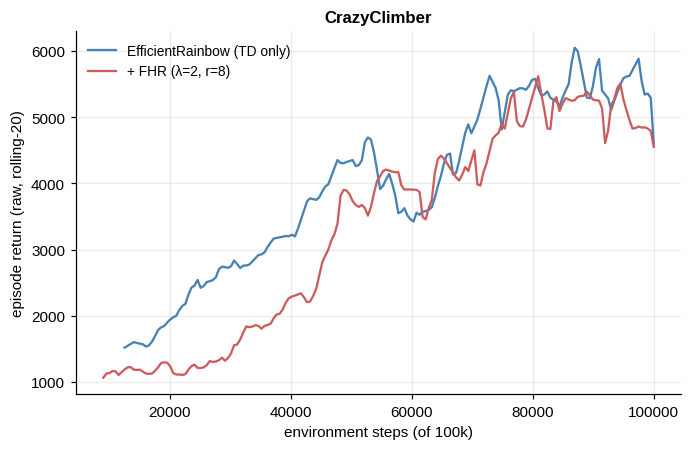

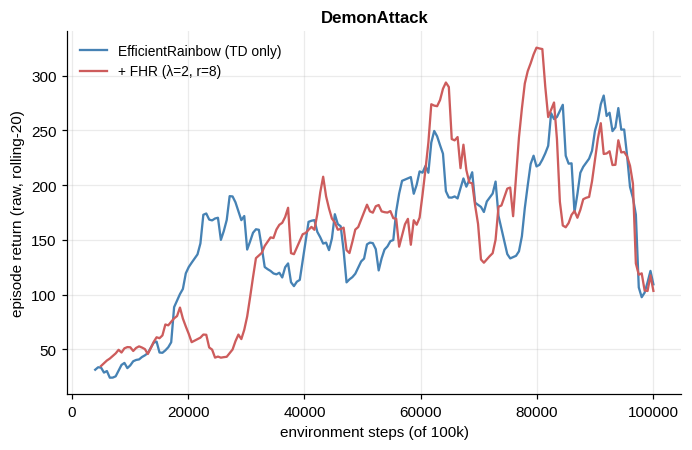

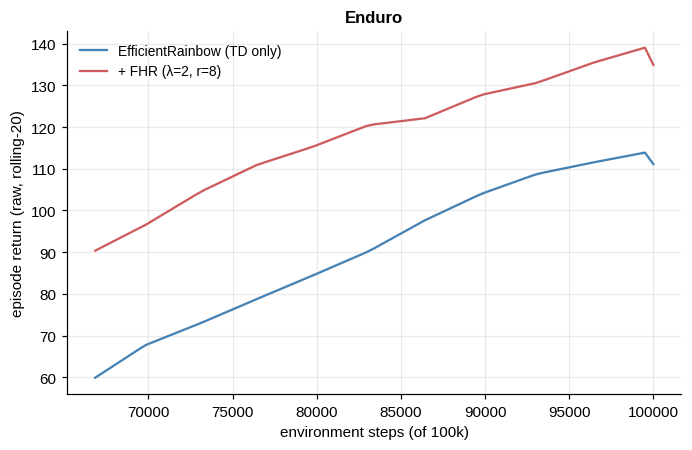

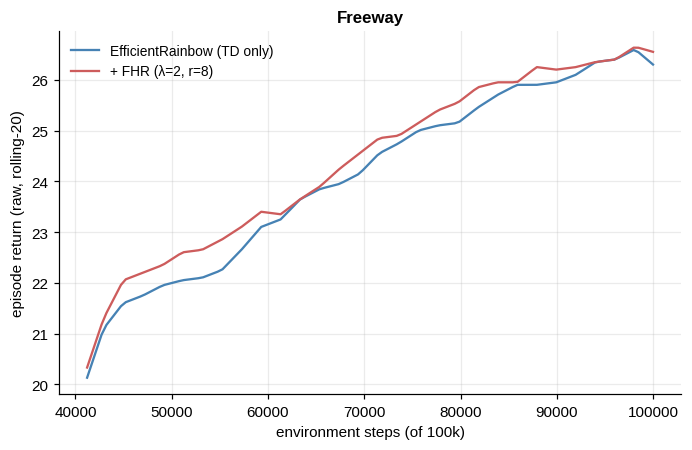

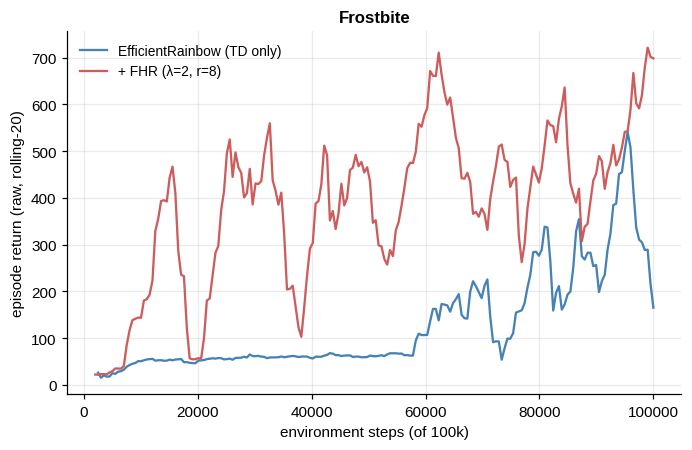

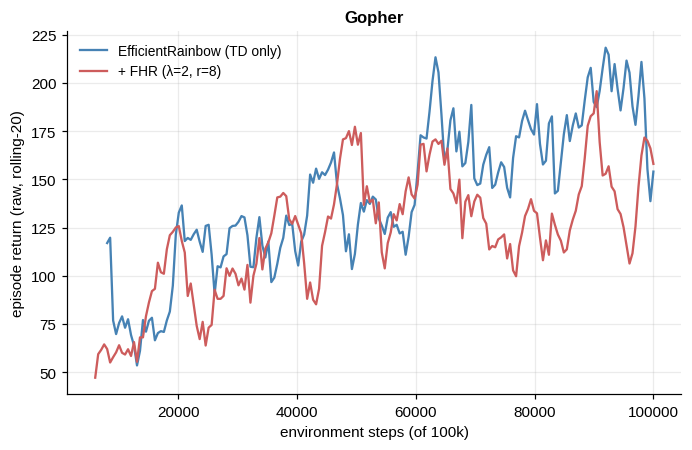

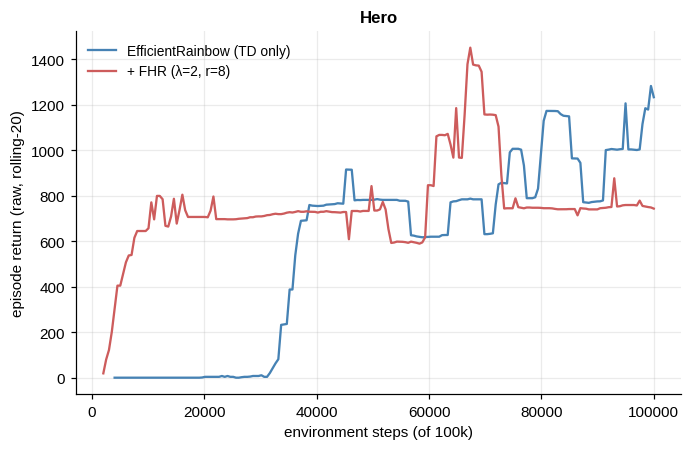

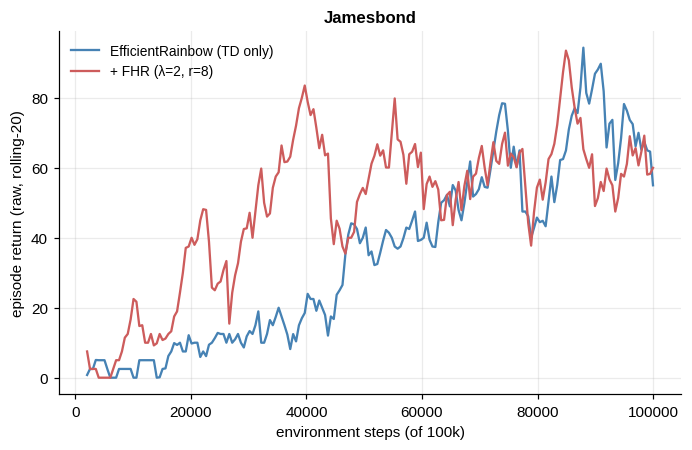

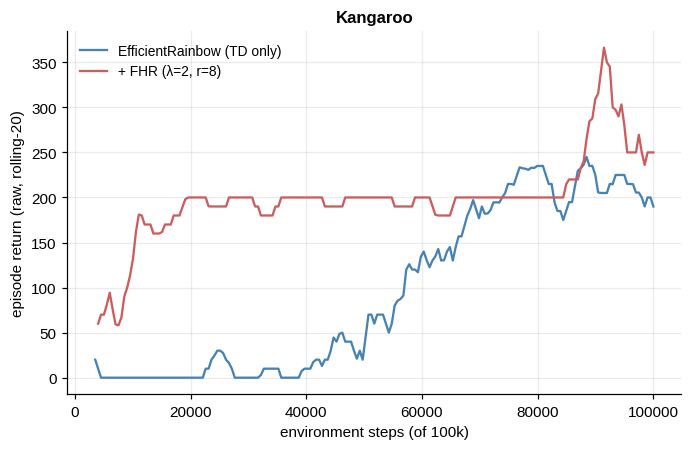

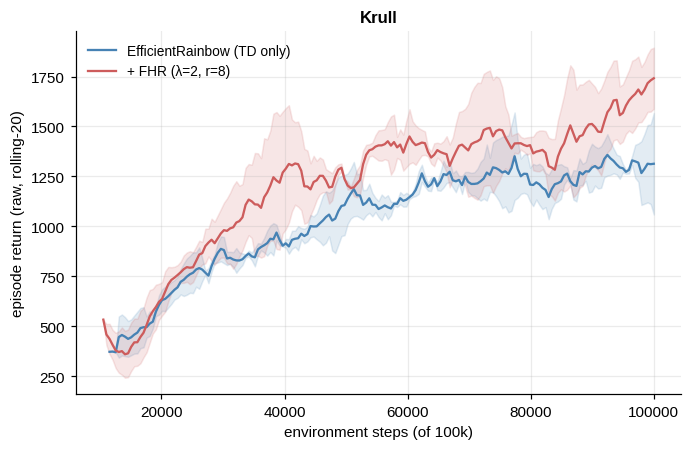

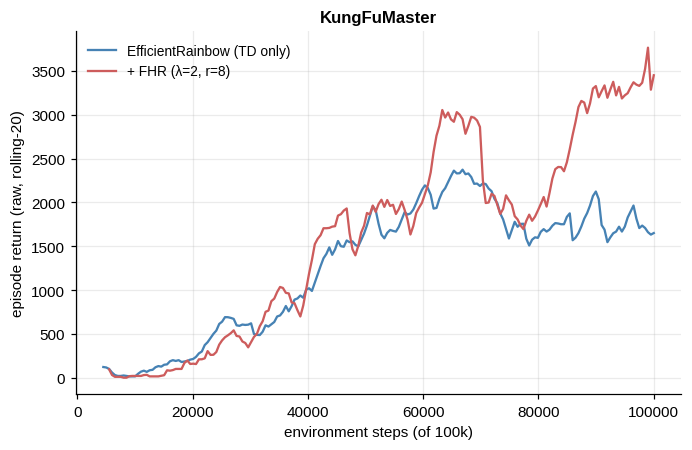

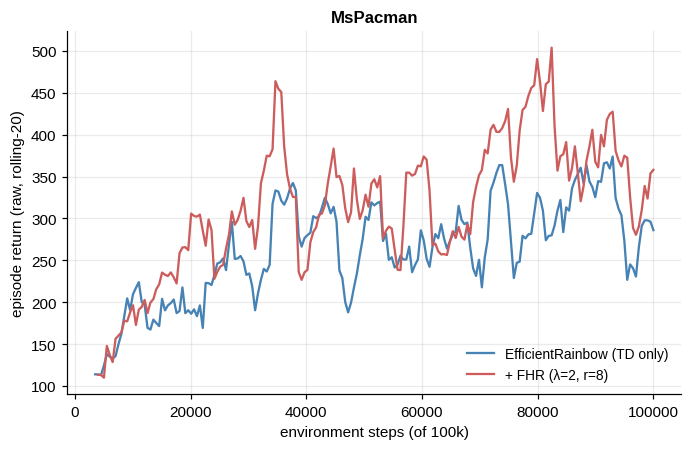

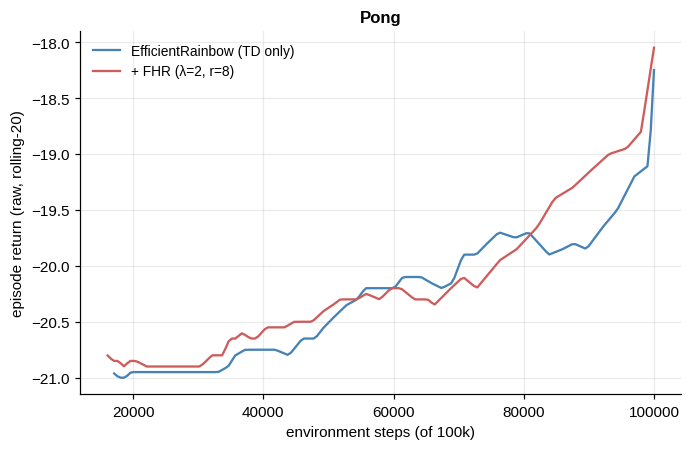

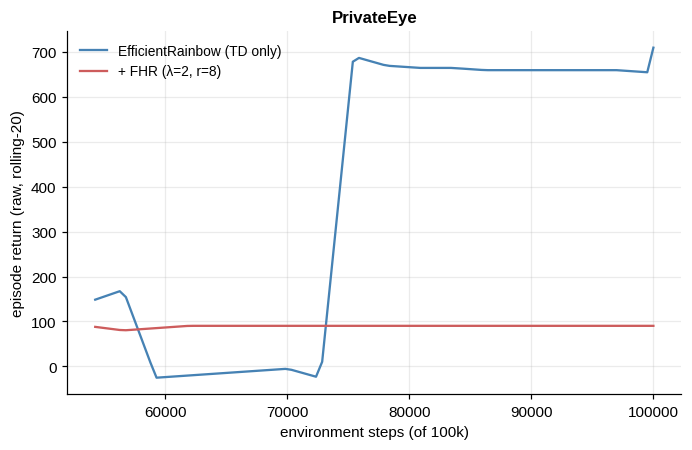

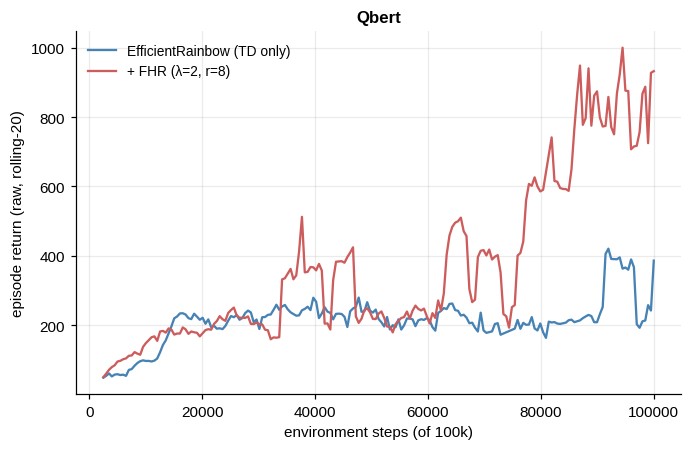

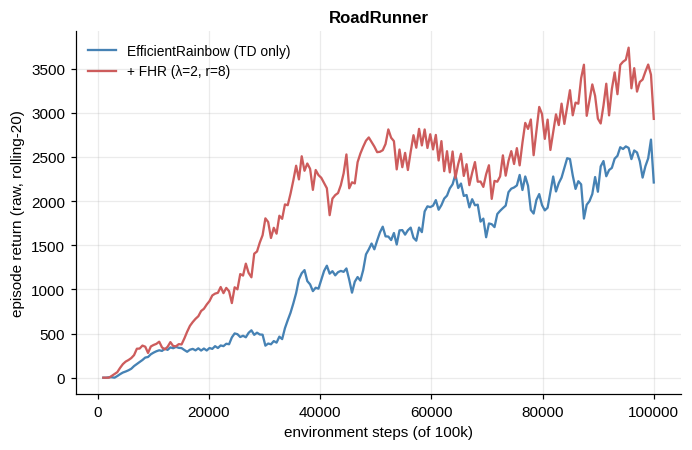

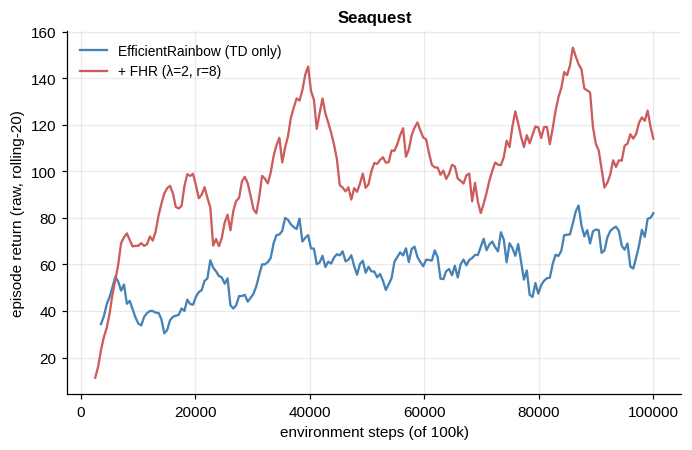

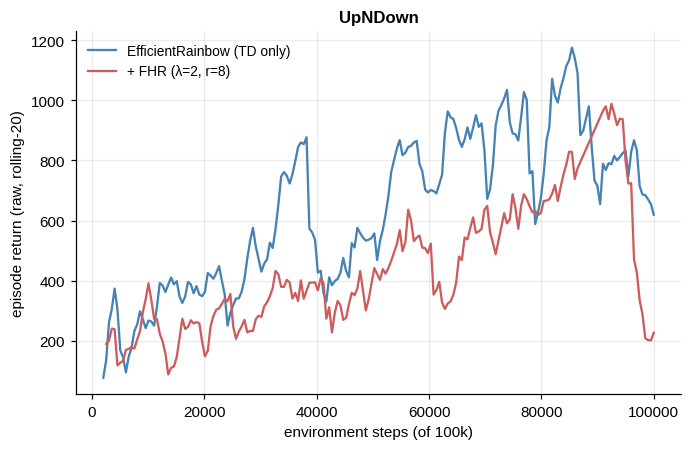

saved 27 figures at 300 dpi -> /home/souparna/Low-Rank-RL-TL/experiments/atari/cached/atari100k_effrainbow_figures/learning_curves


In [6]:
def rolling(x, w):
    x = np.asarray(x, float)
    return x if len(x) < w else np.convolve(x, np.ones(w) / w, mode="valid")

def curve_on_grid(runs, w=20, n=200):
    grid = np.linspace(0, ATARI100K_ENV_STEPS, n)
    stack = np.full((len(runs), n), np.nan)
    for i, r in enumerate(runs):
        steps = np.cumsum(r["steps"]) if r["steps"] is not None else None
        if steps is None or len(r["rewards"]) < w:
            continue
        y = rolling(r["rewards"], w)
        xs = steps[len(steps) - len(y):]
        inside = (grid >= xs[0]) & (grid <= xs[-1])
        stack[i, inside] = np.interp(grid[inside], xs, y)
    return grid, stack

# One standalone figure per game, saved at 300 dpi (poster/paper-ready) under
# cached/atari100k_effrainbow_figures/learning_curves/ and into that game's
# run dirs for the result viewer.
CURVEDIR = FIGDIR / "learning_curves"
CURVEDIR.mkdir(exist_ok=True)
for g in GAMES:
    k = GAME_KEYS[g]
    fig, ax = plt.subplots(figsize=(6.4, 4.2))
    for arm in ARMS:
        if arm not in RESULTS[g]:
            continue
        grid, stack = curve_on_grid(RESULTS[g][arm]["runs"])
        m = np.nanmean(stack, axis=0)
        ax.plot(grid, m, color=OUR_COLOR[arm], label=OUR_LABEL[arm])
        if stack.shape[0] > 1:
            ax.fill_between(grid, np.nanmin(stack, axis=0),
                            np.nanmax(stack, axis=0),
                            color=OUR_COLOR[arm], alpha=0.15)
    ax.set_title(k)
    ax.set_xlabel("environment steps (of 100k)")
    ax.set_ylabel("episode return (raw, rolling-20)")
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(CURVEDIR / f"learning_curve_{k}.png", dpi=300,
                bbox_inches="tight")
    for arm in RESULTS[g]:
        for r in RESULTS[g][arm]["runs"]:
            d = pathlib.Path(r["run_dir"]) / "figures"
            d.mkdir(exist_ok=True)
            fig.savefig(d / "comparison_learning_curve.png", dpi=300,
                        bbox_inches="tight")
    plt.show()
print(f"saved {len(GAMES)} figures at 300 dpi -> {CURVEDIR}")

## 5 · Notes for the write-up

- Cite: protocol — Kaiser et al. 2020 (SimPLe); recipe — Kostrikov et al. 2021
  (DrQ, Table 4 "Efficient DQN") with the IQN-8 head; published columns — Ye et
  al. 2021 Table 1 (EfficientZero); random/human — Wang et al. 2016 (30 no-op).
- The honest claim shape: *"under the EfficientRainbow recipe at replay ratio 2,
  adding λ·Huber(order-8 recurrence residual) to the TD loss changes the 100k
  suite aggregate from X to Y (per-game win/loss W–L)"*. The published methods
  contextualise the axis; they are not matched-recipe ablations.
- exp3's r = 8 matching the HalfCheetah FHR-SAC winner (λ0.1·r8) is worth one
  sentence in the thesis: the longer recurrence window is the cross-domain
  choice, r = 2 the classic-control one.
- Per-run mechanism diagnostics (Hankel rank evolution, penalty traces, learned
  coefficients) are browsable in the result viewer (`python
  result_viewer_app/rank_viewer.py`), manifest family `effrainbow100k_runs`,
  baseline-vs-exp3 compare built in. Krull's deeper arm grid (r = 22 probes,
  gameplay clips, BBF cross-recipe synthesis) stays in
  `dqn_krull/exp_effrainbow_fhr_krull_results.ipynb`.

**Executed 2026-08-28, all 27 games (26-suite + Enduro), corrected protocol:**

- **Full-26-game aggregate HNS**: baseline **0.460 mean / 0.211 median** → +FHR
  **0.544 / 0.259** — an 18% relative lift on mean HNS from the penalty alone.
  That places EfficientRainbow+FHR above SimPLe, OTRainbow, CURL, DrQ and
  MuZero's mean on this table, below SPR (0.703/0.415) and EfficientZero
  (1.943/1.090).
- **Per-game: 15 wins / 11 losses / 1 tie** (raw score, all 27 games);
  ΔHNS mean +0.083, median ≈ 0, IQR [−0.061, +0.047]. The mean lift is carried
  by large wins — Boxing +1.47, Krull +0.77, BankHeist +0.62, Frostbite +0.35 —
  while the typical game is a wash and the worst loss is moderate
  (DemonAttack −0.33). The honest sentence: *FHR substantially helps a subset
  of games and is near-neutral elsewhere; it does not degrade the typical
  game.* One seed per game (Krull 2) — the per-game signs are noisy,
  the aggregate and the win-tally are the quotable numbers.